In [3]:
!pip install tabulate

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.8/40.8 kB 3.4 MB/s eta 0:00:00


Benchmarking onnc_quant...
Benchmarking compressed_pt...
Benchmarking onnx_optimized...


/tmp/ipykernel_479/4153370962.py:102: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_summary, x="Option", y=df_summary["Throughput"].str.extract(r'([\d.]+)').astype(float)[0], ax=axes[0], palette="viridis")
/tmp/ipykernel_479/4153370962.py:107: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=pd.DataFrame(results_data), x="Option", y="Latency (ms)", ax=axes[1], palette="viridis")


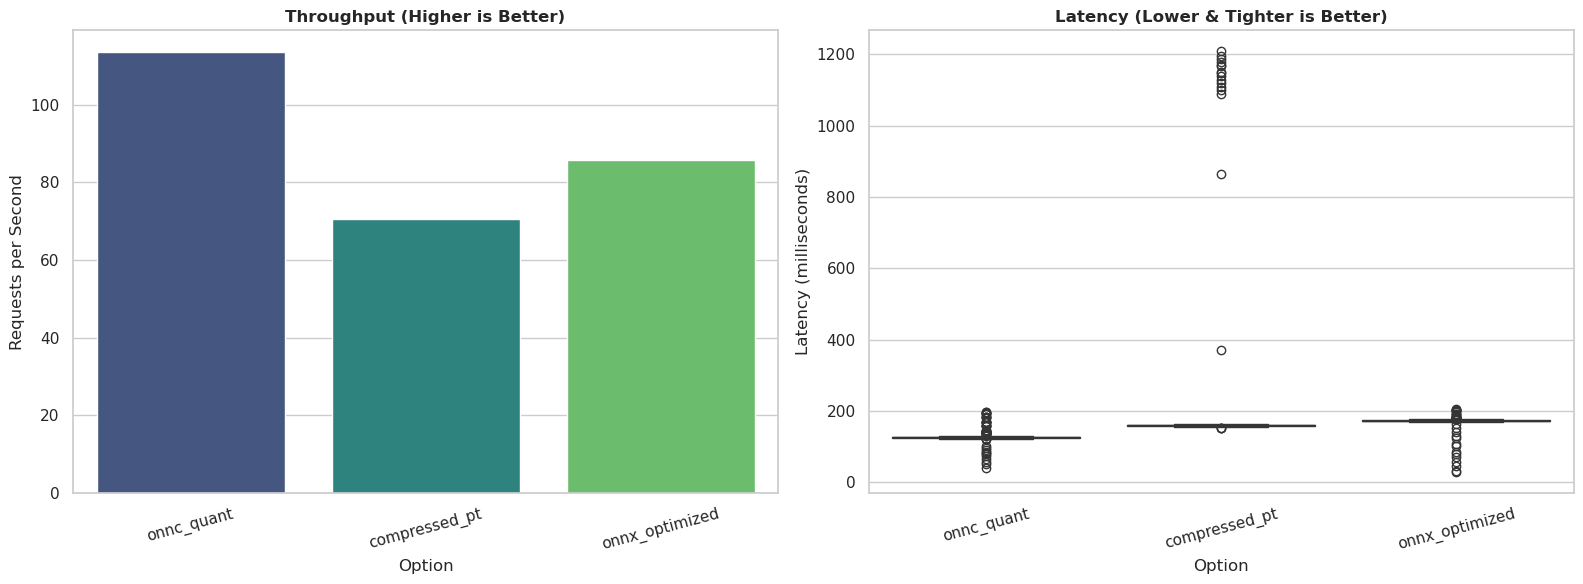


--- FINAL SERVING OPTIONS TABLE ---
| Option         | Endpoint URL                  | Model version             | Code version   | Hardware   | p50/p95 latency   | Throughput   | Error rate   |   Concurrency tested | Compute instance type   | Notes                                           |
|:---------------|:------------------------------|:--------------------------|:---------------|:-----------|:------------------|:-------------|:-------------|---------------------:|:------------------------|:------------------------------------------------|
| onnc_quant     | http://localhost:8004/predict | bert-base-NER (ONNX INT8) | main (HEAD)    | CPU        | 126.1ms / 160.0ms | 113.41 req/s | 0.0%         |                   15 | m1.xlarge               | Simplest reference implementation               |
| compressed_pt  | http://localhost:8003/predict | bert-base-NER (INT8)      | main (HEAD)    | CPU        | 159.6ms / 396.3ms | 70.42 req/s  | 0.0%         |                   15 | m1.xlar

In [12]:
import requests, time, numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from concurrent.futures import ThreadPoolExecutor

payload = {"document_id": "doc_104", "ocr_text": "Invoice total is $500. Due Date: May 1 2026."}

# Define the full metadata for each serving option to match the required table
options_config = [
    {
        "Option": "onnc_quant",
        "Endpoint URL": "http://localhost:8004/predict",
        "Model version": "bert-base-NER (ONNX INT8)",
        "Code version": "main (HEAD)",
        "Hardware": "CPU",
        "Concurrency tested": 15,
        "Compute instance type": "m1.xlarge",
        "Notes": "Simplest reference implementation"
    },
    {
        "Option": "compressed_pt",
        "Endpoint URL": "http://localhost:8003/predict",
        "Model version": "bert-base-NER (INT8)",
        "Code version": "main (HEAD)",
        "Hardware": "CPU",
        "Concurrency tested": 15,
        "Compute instance type": "m1.xlarge",
        "Notes": "Model-level optimization (Dynamic Quantization)"
    },
    {
        "Option": "onnx_optimized",
        "Endpoint URL": "http://localhost:8001/predict",
        "Model version": "bert-base-NER (ONNX)",
        "Code version": "main (HEAD)",
        "Hardware": "CPU",
        "Concurrency tested": 15,
        "Compute instance type": "m1.xlarge",
        "Notes": "Framework optimization"
    }
]

results_data = []
summary_stats = []

def send_req(url):
    s = time.time()
    try:
        res = requests.post(url, json=payload, timeout=5)
        # Return latency AND a boolean indicating if it was an error
        return (time.time() - s), (res.status_code != 200)
    except:
        return None, True # Treat timeouts/connection failures as errors

for config in options_config:
    name = config["Option"]
    url = config["Endpoint URL"]
    concurrency = config["Concurrency tested"]
    
    print(f"Benchmarking {name}...")
    start_total = time.time()
    
    with ThreadPoolExecutor(max_workers=concurrency) as ex:
        # returns list of tuples: (latency, is_error)
        results = list(ex.map(lambda _: send_req(url), range(300)))
    
    # Filter out total failures (None latency), but count errors
    valid_latencies = [r[0] for r in results if r[0] is not None]
    total_errors = sum([1 for r in results if r[1] == True])
    
    if not valid_latencies:
        print(f"  -> WARNING: {name} completely failed.")
        continue
        
    throughput = len(valid_latencies) / (time.time() - start_total)
    error_rate = (total_errors / 300) * 100
    
    p50 = np.percentile(valid_latencies, 50) * 1000
    p95 = np.percentile(valid_latencies, 95) * 1000
    
    for lat in valid_latencies:
        results_data.append({"Option": name, "Latency (ms)": lat * 1000})
        
    summary_stats.append({
        "Option": name,
        "Endpoint URL": url,
        "Model version": config["Model version"],
        "Code version": config["Code version"],
        "Hardware": config["Hardware"],
        "p50/p95 latency": f"{p50:.1f}ms / {p95:.1f}ms",
        "Throughput": f"{throughput:.2f} req/s",
        "Error rate": f"{error_rate:.1f}%",
        "Concurrency tested": concurrency,
        "Compute instance type": config["Compute instance type"],
        "Notes": config["Notes"]
    })

df_summary = pd.DataFrame(summary_stats)

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Extract numeric throughput for the bar chart sorting
sns.barplot(data=df_summary, x="Option", y=df_summary["Throughput"].str.extract(r'([\d.]+)').astype(float)[0], ax=axes[0], palette="viridis")
axes[0].set_title("Throughput (Higher is Better)", fontweight='bold')
axes[0].tick_params(axis='x', rotation=15)
axes[0].set_ylabel("Requests per Second")

sns.boxplot(data=pd.DataFrame(results_data), x="Option", y="Latency (ms)", ax=axes[1], palette="viridis")
axes[1].set_title("Latency (Lower & Tighter is Better)", fontweight='bold')
axes[1].tick_params(axis='x', rotation=15)
axes[1].set_ylabel("Latency (milliseconds)")

plt.tight_layout()
plt.show()

print("\n--- FINAL SERVING OPTIONS TABLE ---")
print(df_summary.to_markdown(index=False))